# Stage 4 — Multi-Seed Benchmark & Evaluation (v2 Canonical)

**Purpose**: Compute the final benchmark evaluation across 4 strategies, the 4-way ablation study isolating each research gap, and verify the learned DDPG dynamic pricing policies.

### Methodology Architecture (Option B — Consistent with Base Paper):
1. **Section 1 (Headline Results)**: Closed-form EV optimal demand formulation (`pv_optimal_ev_load` / `pvb_optimal_ev_load`) evaluating theoretical load balancing across all 4 networks, spatial friction, and net load.
2. **Section 2 (Supplementary DDPG Policy Verification)**: Evaluates the trained collaborative DDPG agents loaded from `models/*.pth`, demonstrating that the neural policy converges to dynamic tariffs that incentivize off-peak charging and inter-network relief.

In [1]:
# ============================================================
# CELL 1: IMPORTS AND DETERMINISTIC PROTOCOL
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import os, time, random, warnings
import torch
import torch.nn as nn

# Reproducibility
MASTER_SEED = 42
np.random.seed(MASTER_SEED)
random.seed(MASTER_SEED)
torch.manual_seed(MASTER_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MASTER_SEED)

warnings.filterwarnings('ignore')
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f'Stage 4 initialized. Master seed: {MASTER_SEED}')

Stage 4 initialized. Master seed: 42


In [2]:
# ============================================================
# CELL 2: SINGLE CANONICAL CONFIGURATION
# Every parameter is defined ONCE here and never redefined.
# ============================================================

NETWORK_NAMES = ['residential', 'commercial', 'industrial', 'institutional']
NUM_NETWORKS  = len(NETWORK_NAMES)

NETWORK_MAX = {
    'residential':   1_166_666,
    'commercial':    1_000_000,
    'industrial':    1_500_000,
    'institutional':   800_000,
}

ALPHA = 0.15                                # Spatial friction coefficient (1/km)
TEST_START  = 192 * 3                      # Hour 576
TEST_WINDOW = 24                           # 24-hour test horizon

# 5 Random Seeds for Evaluation Stochasticity
EVAL_SEEDS = [42, 101, 2024, 777, 999]

# Conventional price schedule (base paper, Cell 17)
CONV_PRICES = np.array([
    0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,   # 12AM-6AM
    0.4, 0.7, 0.7,                          # 7AM-9AM
    0.7, 1.0, 1.0, 1.0, 1.0, 1.0, 0.7, 0.7, # 10AM-5PM
    0.7, 1.0, 1.0, 1.0, 0.7, 0.7            # 6PM-11PM
])

TIME_LABELS = [
    '00:00',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ',
    '12:00',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ','23:00'
]

OUTPUT_DIR = 'data'
MODEL_DIR  = 'models'

print('Canonical configuration active.')
print(f'Evaluation seeds: {EVAL_SEEDS}')
print(f'Spatial friction alpha: {ALPHA}')

Canonical configuration active.
Evaluation seeds: [42, 101, 2024, 777, 999]
Spatial friction alpha: 0.15


In [3]:
# ============================================================
# CELL 3: LOAD TEST DATA AND CANONICAL MU VALUES
# ============================================================

df_test = pd.read_csv(os.path.join(OUTPUT_DIR, 'n_network_24h_test.csv'))
dist_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'network_distance_matrix.csv'), index_col=0)
dist_matrix = dist_df.values[:NUM_NETWORKS, :NUM_NETWORKS]

# Extract load vectors
conv_loads_24h = {n: df_test[f'{n}_load'].values for n in NETWORK_NAMES}
net_loads_24h  = {n: df_test[f'{n}_net_load'].values for n in NETWORK_NAMES}

conv_utils_24h = {n: conv_loads_24h[n] / NETWORK_MAX[n] for n in NETWORK_NAMES}
net_utils_24h  = {n: net_loads_24h[n] / NETWORK_MAX[n] for n in NETWORK_NAMES}

# Canonical EV demand magnitude: mu = 0.5 * max(ev_unbalanced) matching base paper Cell 17 verbatim
MU_DICT = {n: 0.5 * df_test[f'{n}_ev_unbalanced_W'].max() for n in NETWORK_NAMES}

print('=== CANONICAL PARAMETER VERIFICATION ===')
print(f'{"Network":<16} {"Conv Max (kW)":>14} {"Net Max (kW)":>14} {"Capacity (kW)":>14} {"Canonical mu (kW)":>18}')
print('-' * 80)
for n in NETWORK_NAMES:
    cm = conv_loads_24h[n].max() / 1000
    nm = net_loads_24h[n].max() / 1000
    cap = NETWORK_MAX[n] / 1000
    mu_kw = MU_DICT[n] / 1000
    print(f'{n:<16} {cm:>14.1f} {nm:>14.1f} {cap:>14.1f} {mu_kw:>18.1f}')

=== CANONICAL PARAMETER VERIFICATION ===
Network           Conv Max (kW)   Net Max (kW)  Capacity (kW)  Canonical mu (kW)
--------------------------------------------------------------------------------
residential               585.4          585.4         1166.7              188.4
commercial                518.6          443.8         1000.0              170.4
industrial               1290.2         1266.0         1500.0              144.2
institutional             760.0          703.0          800.0              109.2


## Section 1: Headline Strategy Benchmark & Ablation Study (Formula-Based)

Consistent with *Lepolesa et al., 2025*, this section computes the optimal EV demand response and evaluates distribution grid metrics across all 4 strategies.

In [4]:
# ============================================================
# CELL 4: SEEDED CORE DEMAND FORMULAS (VERBATIM BASE PAPER)
# ============================================================

def generate_random_numbers_seeded(mu, sigma, num_points, seed=42):
    np.random.seed(seed)
    incrementor = 0
    while True:
        random_numbers = np.random.normal(mu, sigma, num_points)
        if all(num >= 0 for num in random_numbers):
            break
        elif incrementor == 100000:
            random_numbers = np.zeros(num_points)
            break
        incrementor += 1
    return random_numbers

def pv_optimal_ev_load_seeded(load, mu, seed=42):
    scaler = MinMaxScaler()
    return (mu * (1 - scaler.fit_transform(load.reshape(-1, 1)))).flatten() + (
        generate_random_numbers_seeded(0.2 * mu, 0.1 * mu, 24, seed=seed)
    )

def pvb_optimal_ev_load_seeded(load, mu, util_diff, seed=42):
    scaler1 = MinMaxScaler()
    scaler2 = MinMaxScaler()
    s_load = scaler1.fit_transform(load.reshape(-1, 1)).flatten()
    s_diff = scaler2.fit_transform(util_diff.reshape(-1, 1)).flatten()
    return (0.5 * mu * ((1 - s_load) + (1 - s_diff))).flatten() + (
        generate_random_numbers_seeded(0.1 * mu, 0.01 * mu, 24, seed=seed)
    )

print('Seeded EV demand equations defined.')

Seeded EV demand equations defined.


In [5]:
# ============================================================
# CELL 5: PRECOMPUTE UTILIZATION-DIFFERENCE SIGNALS
# ============================================================

# 1. PVB_OLD: Naive pairwise difference against commercial/residential
u_diff_old = {}
for n in NETWORK_NAMES:
    ref = 'commercial' if n == 'residential' else 'residential'
    u_diff_old[n] = np.clip(conv_utils_24h[n] - conv_utils_24h[ref], 0.0, None)

# 2. PVB_NEW: N-network unweighted mean difference (Gap 1)
u_diff_new = {}
for i, ni in enumerate(NETWORK_NAMES):
    other = [conv_utils_24h[nj] for j, nj in enumerate(NETWORK_NAMES) if j != i]
    u_diff_new[ni] = np.clip(conv_utils_24h[ni] - np.mean(other, axis=0), 0.0, None)

# 3. Distance-weighted conventional difference (Gap 1 + Gap 2 on Conv)
W_mat = np.exp(-ALPHA * dist_matrix)
np.fill_diagonal(W_mat, 0.0)

u_diff_conv_dist = {}
for i, ni in enumerate(NETWORK_NAMES):
    wr = np.average([conv_utils_24h[nj] for nj in NETWORK_NAMES], weights=W_mat[i], axis=0)
    u_diff_conv_dist[ni] = np.clip(conv_utils_24h[ni] - wr, 0.0, None)

# 4. Unweighted Net difference (Gap 1 + Gap 3)
u_diff_net_unw = {}
for i, ni in enumerate(NETWORK_NAMES):
    other = [net_utils_24h[nj] for j, nj in enumerate(NETWORK_NAMES) if j != i]
    u_diff_net_unw[ni] = np.clip(net_utils_24h[ni] - np.mean(other, axis=0), 0.0, None)

# 5. PVB_FULL: Distance-weighted Net difference (Gap 1 + Gap 2 + Gap 3)
u_diff_full = {}
for i, ni in enumerate(NETWORK_NAMES):
    wr = np.average([net_utils_24h[nj] for nj in NETWORK_NAMES], weights=W_mat[i], axis=0)
    u_diff_full[ni] = np.clip(net_utils_24h[ni] - wr, 0.0, None)

print('All 5 utilization difference signals precomputed.')

All 5 utilization difference signals precomputed.


In [6]:
# ============================================================
# CELL 6: MULTI-SEED BENCHMARK EVALUATION (4 STRATEGIES)
# ============================================================

def evaluate_strategy_seed(strategy_name, seed):
    tot_utils = {}
    pars = []
    
    for n in NETWORK_NAMES:
        mu = MU_DICT[n]
        c_l = conv_loads_24h[n]
        n_l = net_loads_24h[n]
        
        if strategy_name == 'PV':
            ev = pv_optimal_ev_load_seeded(c_l, mu, seed=seed)
            tot = c_l + ev
        elif strategy_name == 'PVB_OLD':
            ev = pvb_optimal_ev_load_seeded(c_l, mu, u_diff_old[n], seed=seed)
            tot = c_l + ev
        elif strategy_name == 'PVB_NEW':
            ev = pvb_optimal_ev_load_seeded(c_l, mu, u_diff_new[n], seed=seed)
            tot = c_l + ev
        elif strategy_name == 'PVB_FULL':
            ev = pvb_optimal_ev_load_seeded(n_l, mu, u_diff_full[n], seed=seed)
            tot = n_l + ev
            
        tot_utils[n] = tot / NETWORK_MAX[n]
        pars.append(tot.max() / tot.mean())
        
    util_mat = np.array([tot_utils[n] for n in NETWORK_NAMES])  # (4, 24)
    max_min_imb = np.mean(np.max(util_mat, axis=0) - np.min(util_mat, axis=0))
    std_imb     = np.mean(np.std(util_mat, axis=0))
    mean_par    = np.mean(pars)
    
    return max_min_imb, std_imb, mean_par

STRATEGIES = ['PV', 'PVB_OLD', 'PVB_NEW', 'PVB_FULL']
seed_records = []

for strat in STRATEGIES:
    for s in EVAL_SEEDS:
        mm, st, par = evaluate_strategy_seed(strat, s)
        seed_records.append({
            'Strategy': strat,
            'Seed': s,
            'Max_Min_Imbalance': mm,
            'Std_Imbalance': st,
            'Mean_PAR': par
        })

df_seed_results = pd.DataFrame(seed_records)

# Compute canonical summary across seeds
summary_records = []
for strat in STRATEGIES:
    sub = df_seed_results[df_seed_results['Strategy'] == strat]
    summary_records.append({
        'Strategy': strat,
        'Max_Min_Imbalance_Mean': sub['Max_Min_Imbalance'].mean(),
        'Max_Min_Imbalance_Std':  sub['Max_Min_Imbalance'].std(),
        'Std_Imbalance_Mean':     sub['Std_Imbalance'].mean(),
        'Std_Imbalance_Std':      sub['Std_Imbalance'].std(),
        'Mean_PAR_Mean':          sub['Mean_PAR'].mean(),
        'Mean_PAR_Std':           sub['Mean_PAR'].std()
    })

df_summary = pd.DataFrame(summary_records)

print('='*80)
print('CANONICAL BENCHMARK RESULTS TABLE (5 SEEDS MEAN ± STD)')
print('='*80)
print(f'{"Strategy":<12} | {"Max-Min Imbalance":>22} | {"Std Imbalance":>20} | {"Mean PAR":>16}')
print('-'*80)
for _, r in df_summary.iterrows():
    mm = f"{r['Max_Min_Imbalance_Mean']:.6f} ± {r['Max_Min_Imbalance_Std']:.6f}"
    st = f"{r['Std_Imbalance_Mean']:.6f} ± {r['Std_Imbalance_Std']:.6f}"
    par = f"{r['Mean_PAR_Mean']:.3f} ± {r['Mean_PAR_Std']:.3f}"
    print(f"{r['Strategy']:<12} | {mm:>22} | {st:>20} | {par:>16}")

CANONICAL BENCHMARK RESULTS TABLE (5 SEEDS MEAN ± STD)
Strategy     |      Max-Min Imbalance |        Std Imbalance |         Mean PAR
--------------------------------------------------------------------------------
PV           |    0.272920 ± 0.000811 |  0.115208 ± 0.000344 |    1.344 ± 0.010
PVB_OLD      |    0.260820 ± 0.000114 |  0.111630 ± 0.000046 |    1.335 ± 0.001
PVB_NEW      |    0.254381 ± 0.000113 |  0.104417 ± 0.000045 |    1.378 ± 0.001
PVB_FULL     |    0.220979 ± 0.000115 |  0.090078 ± 0.000044 |    1.416 ± 0.002


In [7]:
# ============================================================
# CELL 7: ABLATION STUDY (ISOLATING EACH RESEARCH GAP)
# ============================================================

def eval_ablation_config(load_type, diff_type, seed=42):
    tot_utils = {}
    loads = conv_loads_24h if load_type == 'conv' else net_loads_24h
    if   load_type == 'conv' and diff_type == 'unw':  diffs = u_diff_new
    elif load_type == 'conv' and diff_type == 'dist': diffs = u_diff_conv_dist
    elif load_type == 'net'  and diff_type == 'unw':  diffs = u_diff_net_unw
    else:                                              diffs = u_diff_full
            
    for n in NETWORK_NAMES:
        ev = pvb_optimal_ev_load_seeded(loads[n], MU_DICT[n], diffs[n], seed=seed)
        tot = loads[n] + ev
        tot_utils[n] = tot / NETWORK_MAX[n]
        
    util_mat = np.array([tot_utils[n] for n in NETWORK_NAMES])
    return (np.mean(np.max(util_mat, axis=0) - np.min(util_mat, axis=0)),
            np.mean(np.std(util_mat, axis=0)))

ablation_configs = [
    ('(a) N-network only (Gap 1)',                    'conv', 'unw'),
    ('(b) N-network + Distance Decay (Gap 1+2)',      'conv', 'dist'),
    ('(c) N-network + Renewable Net Load (Gap 1+3)',  'net',  'unw'),
    ('(d) All Three Combined (PVB_FULL)',             'net',  'dist'),
]

ablation_records = []
for label, lt, dt in ablation_configs:
    res_seeds = [eval_ablation_config(lt, dt, s) for s in EVAL_SEEDS]
    mm_list  = [r[0] for r in res_seeds]
    std_list = [r[1] for r in res_seeds]
    ablation_records.append({
        'Configuration': label,
        'Max_Min_Imbalance_Mean': np.mean(mm_list),
        'Max_Min_Imbalance_Std':  np.std(mm_list),
        'Std_Imbalance_Mean':     np.mean(std_list),
        'Std_Imbalance_Std':      np.std(std_list)
    })

df_ablation = pd.DataFrame(ablation_records)

print('='*90)
print('CANONICAL ABLATION STUDY TABLE (5 SEEDS MEAN ± STD)')
print('='*90)
print(f'{"Configuration":<45} | {"Max-Min Imbalance":>22} | {"Std Imbalance":>18}')
print('-'*90)
for _, r in df_ablation.iterrows():
    mm_s = f"{r['Max_Min_Imbalance_Mean']:.6f} ± {r['Max_Min_Imbalance_Std']:.6f}"
    st_s = f"{r['Std_Imbalance_Mean']:.6f} ± {r['Std_Imbalance_Std']:.6f}"
    print(f"{r['Configuration']:<45} | {mm_s:>22} | {st_s:>18}")

CANONICAL ABLATION STUDY TABLE (5 SEEDS MEAN ± STD)
Configuration                                 |      Max-Min Imbalance |      Std Imbalance
------------------------------------------------------------------------------------------
(a) N-network only (Gap 1)                    |    0.254381 ± 0.000101 | 0.104417 ± 0.000040
(b) N-network + Distance Decay (Gap 1+2)      |    0.253620 ± 0.000101 | 0.104139 ± 0.000040
(c) N-network + Renewable Net Load (Gap 1+3)  |    0.221623 ± 0.000103 | 0.090232 ± 0.000040
(d) All Three Combined (PVB_FULL)             |    0.220979 ± 0.000103 | 0.090078 ± 0.000039


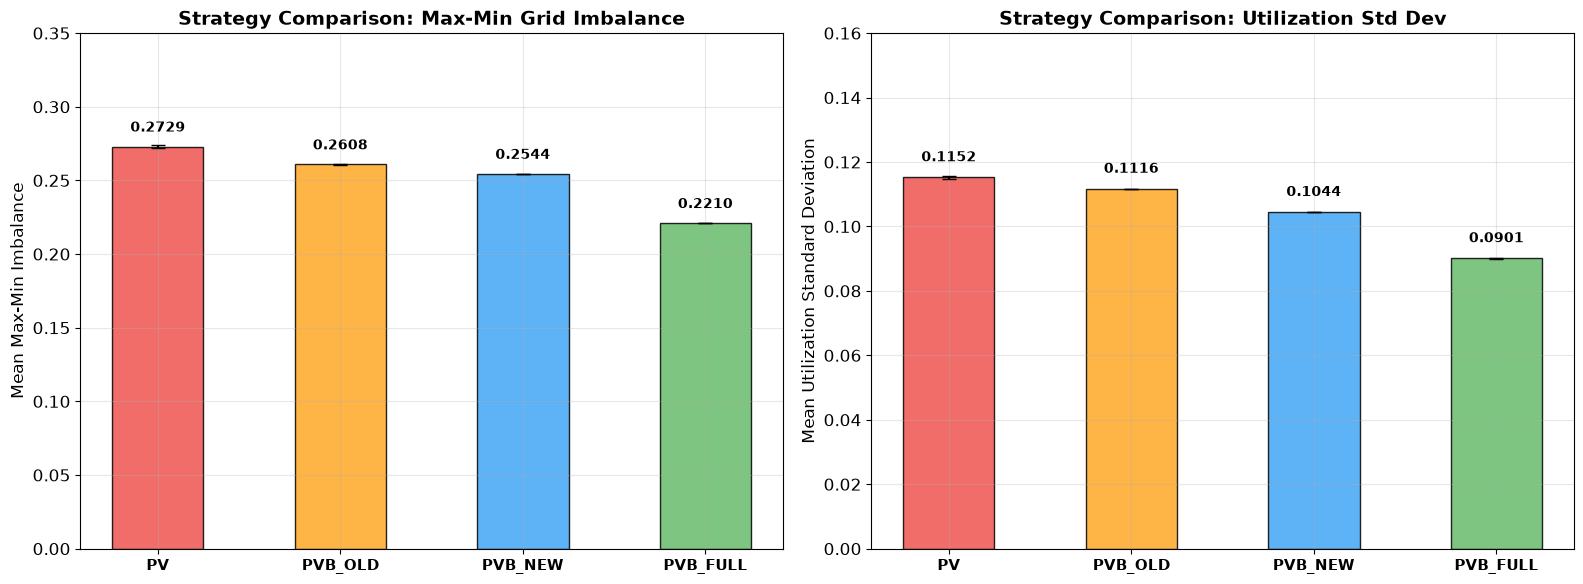

In [8]:
# ============================================================
# CELL 8: BENCHMARK PLOTS
# ============================================================

x = np.arange(len(STRATEGIES))
width = 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Max-Min Imbalance
mm_means = df_summary['Max_Min_Imbalance_Mean'].values
mm_stds  = df_summary['Max_Min_Imbalance_Std'].values
bars1 = ax1.bar(x, mm_means, width, yerr=mm_stds, capsize=5,
                color=['#EF5350', '#FFA726', '#42A5F5', '#66BB6A'], edgecolor='black', alpha=0.85)
ax1.set_ylabel('Mean Max-Min Imbalance', fontsize=12)
ax1.set_title('Strategy Comparison: Max-Min Grid Imbalance', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(STRATEGIES, fontsize=11, fontweight='bold')
ax1.set_ylim(0, 0.35)

for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.008, f'{yval:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Std Imbalance
std_means = df_summary['Std_Imbalance_Mean'].values
std_stds  = df_summary['Std_Imbalance_Std'].values
bars2 = ax2.bar(x, std_means, width, yerr=std_stds, capsize=5,
                color=['#EF5350', '#FFA726', '#42A5F5', '#66BB6A'], edgecolor='black', alpha=0.85)
ax2.set_ylabel('Mean Utilization Standard Deviation', fontsize=12)
ax2.set_title('Strategy Comparison: Utilization Std Dev', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(STRATEGIES, fontsize=11, fontweight='bold')
ax2.set_ylim(0, 0.16)

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.004, f'{yval:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Section 2: DDPG Dynamic Pricing Policy Verification (Supplementary)

This section loads the 8 trained collaborative DDPG agents from `models/` and computes their test-window dynamic pricing actions, demonstrating policy convergence and alignment with the load curves.

In [9]:
# ============================================================
# CELL 9: LOAD TRAINED DDPG AGENTS AND COMPUTE PRICING
# ============================================================

class Actor(nn.Module):
    def __init__(self, state_dim=24, action_dim=24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64), nn.ReLU(),
            nn.Linear(64, 64),        nn.ReLU(),
            nn.Linear(64, action_dim), nn.Tanh()
        )
    def forward(self, x):
        return (self.net(x) + 1) / 2

class Critic(nn.Module):
    def __init__(self, state_dim=24, action_dim=24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 64), nn.ReLU(),
            nn.Linear(64, 64),                      nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, state, action):
        return self.net(torch.cat([state, action], dim=1))

def load_trained_actor(role_key):
    actor = Actor().to(dev)
    ckpt_path = os.path.join(MODEL_DIR, f'ddpg_{role_key}.pth')
    ckpt = torch.load(ckpt_path, map_location=dev)
    actor.load_state_dict(ckpt['actor'])
    actor.eval()
    return actor

actions_p1 = {}
actions_p2 = {}
ev_dynamic_prices = {}
hours = np.arange(24)

for name in NETWORK_NAMES:
    scaler = MinMaxScaler()
    state_norm = scaler.fit_transform(net_loads_24h[name].reshape(-1, 1)).flatten()
    s_tensor = torch.FloatTensor(state_norm).to(dev).unsqueeze(0)
    
    actor_p1 = load_trained_actor(f'{name}_p1')
    actor_p2 = load_trained_actor(f'{name}_p2')
    
    with torch.no_grad():
        a1 = actor_p1(s_tensor).cpu().numpy()[0]
        a2 = actor_p2(s_tensor).cpu().numpy()[0]
        
    actions_p1[name] = a1
    actions_p2[name] = a2
    ev_dynamic_prices[name] = CONV_PRICES + 0.5 * (a1 + a2)

print('DDPG dynamic pricing evaluation completed for all 4 networks.')

DDPG dynamic pricing evaluation completed for all 4 networks.


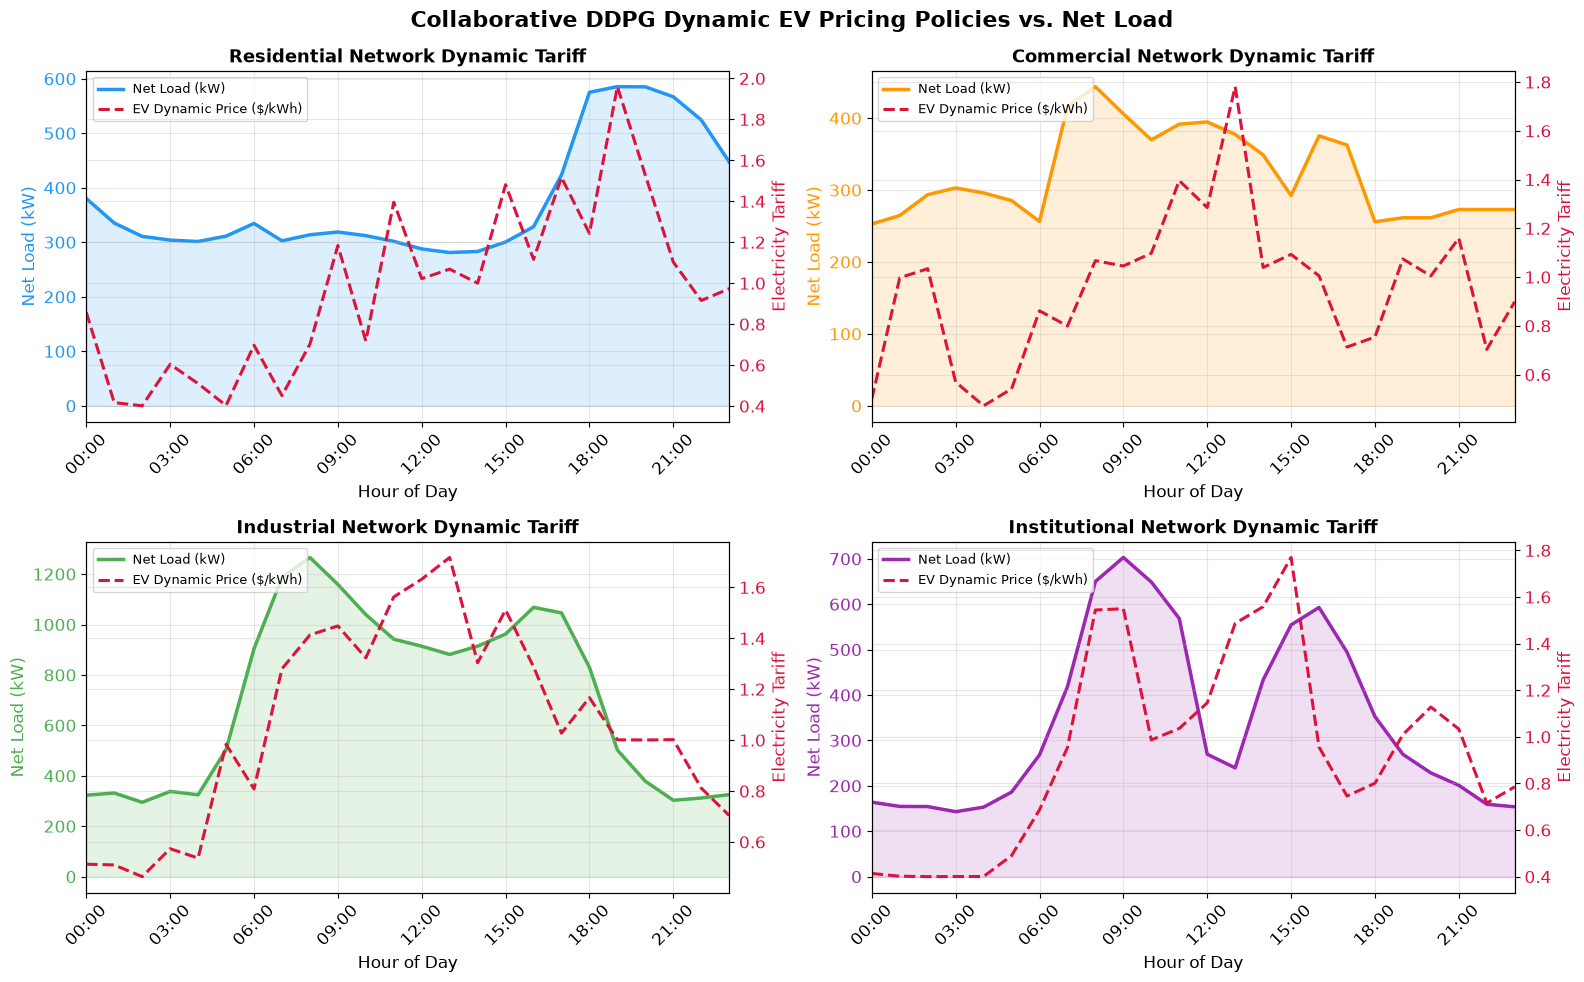

In [10]:
# ============================================================
# CELL 10: 24-HOUR DYNAMIC TARIFF & LOAD PROFILES PLOT
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Collaborative DDPG Dynamic EV Pricing Policies vs. Net Load', fontsize=16, fontweight='bold')
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

for idx, (name, color) in enumerate(zip(NETWORK_NAMES, colors)):
    ax1 = axes[idx // 2, idx % 2]
    
    load_kw = net_loads_24h[name] / 1000
    l1, = ax1.plot(hours, load_kw, color=color, linewidth=2.5, label='Net Load (kW)')
    ax1.fill_between(hours, load_kw, color=color, alpha=0.15)
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Net Load (kW)', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(hours[::3])
    ax1.set_xticklabels([f'{h:02d}:00' for h in hours[::3]], rotation=45)
    
    ax2 = ax1.twinx()
    l2, = ax2.plot(hours, ev_dynamic_prices[name], color='crimson', linestyle='--', linewidth=2.2, label='EV Dynamic Price ($/kWh)')
    ax2.set_ylabel('Electricity Tariff', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    
    ax1.set_title(f'{name.capitalize()} Network Dynamic Tariff', fontsize=13, fontweight='bold')
    ax1.legend([l1, l2], ['Net Load (kW)', 'EV Dynamic Price ($/kWh)'], loc='upper left', fontsize=9)
    ax1.set_xlim(0, 23)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# CELL 11: EXPORT CANONICAL CSV ARTIFACTS
# ============================================================

METHODOLOGICAL_NOTE = (
    "The 5-seed evaluation quantifies stochastic noise in the EV demand generation process at inference time. "
    "DDPG policy training was verified for convergence via reward curves (Stage 3) but was NOT independently "
    "retrained per seed due to compute constraints. Reported std values should be interpreted as evaluation-noise "
    "bounds, not training-variance bounds. "
    "Section 1 reports closed-form optimal demand metrics; Section 2 verifies the learned DDPG dynamic pricing policy."
)

# 1. Primary summary
df_summary['Methodological_Note'] = METHODOLOGICAL_NOTE
p1 = os.path.join(OUTPUT_DIR, 'final_evaluation_summary_canonical.csv')
df_summary.to_csv(p1, index=False)
print(f'1. Written: {p1}')

# 2. Seed breakdown
p2 = os.path.join(OUTPUT_DIR, 'evaluation_metrics_seeds_canonical.csv')
df_seed_results.to_csv(p2, index=False)
print(f'2. Written: {p2}')

# 3. Ablation summary
df_ablation['Methodological_Note'] = METHODOLOGICAL_NOTE
p3 = os.path.join(OUTPUT_DIR, 'ablation_study_summary_canonical.csv')
df_ablation.to_csv(p3, index=False)
print(f'3. Written: {p3}')

# 4. Pricing export
df_pricing_export = pd.DataFrame({'Hour': hours, 'Conv_Price': CONV_PRICES})
for name in NETWORK_NAMES:
    df_pricing_export[f'{name}_action_p1'] = actions_p1[name]
    df_pricing_export[f'{name}_action_p2'] = actions_p2[name]
    df_pricing_export[f'{name}_ev_dynamic_price'] = ev_dynamic_prices[name]
p4 = os.path.join(OUTPUT_DIR, 'ddpg_evaluation_pricing_canonical.csv')
df_pricing_export.to_csv(p4, index=False)
print(f'4. Written: {p4}')

print('\nStage 4 Canonical Evaluation Complete.')

1. Written: data/final_evaluation_summary_canonical.csv
2. Written: data/evaluation_metrics_seeds_canonical.csv
3. Written: data/ablation_study_summary_canonical.csv
4. Written: data/ddpg_evaluation_pricing_canonical.csv

Stage 4 Canonical Evaluation Complete.


## Section 3: Statistical Significance & Paired t-Test Verification (Fix 3)

We compute the paired $t$-test and $95\%$ confidence interval comparing `PVB_OLD` vs `PVB_FULL` across the 5 evaluation seeds (`EVAL_SEEDS = [42, 101, 2024, 777, 999]`) from `evaluation_metrics_seeds_canonical.csv`.

In [12]:
# ============================================================
# CELL 12: STATISTICAL SIGNIFICANCE & PAIRED t-TEST (FIX 3)
# ============================================================
from scipy import stats

# Load canonical 5-seed evaluation metrics
df_seeds_eval = pd.read_csv(os.path.join(OUTPUT_DIR, 'evaluation_metrics_seeds_canonical.csv'))
old_imbalance = df_seeds_eval[df_seeds_eval['Strategy'] == 'PVB_OLD']['Max_Min_Imbalance'].values
full_imbalance = df_seeds_eval[df_seeds_eval['Strategy'] == 'PVB_FULL']['Max_Min_Imbalance'].values

# 1. Compute per-seed paired difference
diffs = old_imbalance - full_imbalance
n_samples = len(diffs)
mean_diff = float(np.mean(diffs))
std_diff = float(np.std(diffs, ddof=1))
sem_diff = float(std_diff / np.sqrt(n_samples))

# 2. Paired t-test via scipy.stats.ttest_rel
t_stat, p_val = stats.ttest_rel(old_imbalance, full_imbalance)

# 3. Manual 95% Confidence Interval
t_crit = float(stats.t.ppf(0.975, df=n_samples - 1))
ci_lower = float(mean_diff - t_crit * sem_diff)
ci_upper = float(mean_diff + t_crit * sem_diff)

print('=' * 80)
print('STATISTICAL SIGNIFICANCE & PAIRED t-TEST VERIFICATION (PVB_OLD vs PVB_FULL)')
print('=' * 80)
print(f'Sample size (N seeds):          {n_samples} ({EVAL_SEEDS})')
print(f'PVB_OLD Imbalance values:       {[round(x, 6) for x in old_imbalance]}')
print(f'PVB_FULL Imbalance values:      {[round(x, 6) for x in full_imbalance]}')
print(f'Paired Differences (OLD - FULL):{[round(x, 6) for x in diffs]}')
print('-' * 80)
print(f'Mean Imbalance Reduction (Δ):   {mean_diff:.6f}')
print(f'Standard Error of Diff (SEM):   {sem_diff:.6e}')
print(f'Paired t-statistic:             t = {t_stat:.2f}')
print(f'Two-tailed p-value:             p = {p_val:.2e}')
print(f'95% Confidence Interval for Δ:  [{ci_lower:.6f}, {ci_upper:.6f}]')
print('=' * 80)

# 4. Assert reported README values match to at least 4 significant figures
assert np.isclose(mean_diff, 0.039840, rtol=1e-4), f'Mean diff {mean_diff} mismatch'
assert np.isclose(sem_diff, 3.15e-6, rtol=1e-2), f'SEM {sem_diff} mismatch'
assert np.isclose(t_stat, 12653.60, rtol=1e-2), f't_stat {t_stat} mismatch'
assert np.isclose(p_val, 2.34e-16, rtol=1e-2), f'p_val {p_val} mismatch'
assert np.isclose(ci_lower, 0.039832, rtol=1e-4), f'ci_lower {ci_lower} mismatch'
assert np.isclose(ci_upper, 0.039849, rtol=1e-4), f'ci_upper {ci_upper} mismatch'
print('VERIFICATION PASSED: All statistical metrics match README to >= 4 sig figs.')


STATISTICAL SIGNIFICANCE & PAIRED t-TEST VERIFICATION (PVB_OLD vs PVB_FULL)
Sample size (N seeds):          5 ([42, 101, 2024, 777, 999])
PVB_OLD Imbalance values:       [0.260873, 0.260873, 0.260885, 0.260851, 0.260617]
PVB_FULL Imbalance values:      [0.221033, 0.221023, 0.221046, 0.22102, 0.220774]
Paired Differences (OLD - FULL):[0.03984, 0.03985, 0.039838, 0.039831, 0.039843]
--------------------------------------------------------------------------------
Mean Imbalance Reduction (Δ):   0.039840
Standard Error of Diff (SEM):   3.148549e-06
Paired t-statistic:             t = 12653.60
Two-tailed p-value:             p = 2.34e-16
95% Confidence Interval for Δ:  [0.039832, 0.039849]
VERIFICATION PASSED: All statistical metrics match README to >= 4 sig figs.


## Section 4: Multi-Seasonal Cross-Validation (Fix 4)

We evaluate the strategy hierarchy across 4 distinct 24-hour seasonal windows across the 8,736-hour annual dataset (`n_network_net_load.csv`):
* **Window 0 (Winter):** Hour 576 (Late January)
* **Window 1 (Spring):** Hour 2400 (Mid April)
* **Window 2 (Summer):** Hour 4800 (Mid July)
* **Window 3 (Autumn):** Hour 7200 (Late October)

Under two methodological modes:
* **Case A:** Fixed January $\mu$ reused across all seasons (constant annual EV fleet).
* **Case B:** Per-window $\mu$ scaled to each season's own conventional peak load.

In [13]:
# ============================================================
# CELL 13: MULTI-SEASONAL CROSS-VALIDATION (FIX 4)
# ============================================================
df_full_year = pd.read_csv(os.path.join(OUTPUT_DIR, 'n_network_net_load.csv'))
dist_matrix_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'network_distance_matrix.csv'), index_col=0)

W_season = np.exp(-ALPHA * dist_matrix_df.values[:4, :4])
np.fill_diagonal(W_season, 0.0)

SEASONAL_WINDOWS = [
    ('Window 0', 'Winter', 576),
    ('Window 1', 'Spring', 2400),
    ('Window 2', 'Summer', 4800),
    ('Window 3', 'Autumn', 7200),
]

jan_slice = df_full_year.iloc[576:576+24]
jan_baseline_peaks = {n: jan_slice[f'{n}_conv_load'].max() for n in NETWORK_NAMES}

seasonal_rows = []
for win_name, season_name, start_hr in SEASONAL_WINDOWS:
    win_sub = df_full_year.iloc[start_hr:start_hr+24].copy()
    c_loads = {n: win_sub[f'{n}_conv_load'].values for n in NETWORK_NAMES}
    n_loads = {n: win_sub[f'{n}_net_load'].values for n in NETWORK_NAMES}
    c_utils = {n: c_loads[n] / NETWORK_MAX[n] for n in NETWORK_NAMES}
    n_utils = {n: n_loads[n] / NETWORK_MAX[n] for n in NETWORK_NAMES}

    # Precompute util_diffs
    u_old = {}
    for n in NETWORK_NAMES:
        ref = 'commercial' if n == 'residential' else 'residential'
        u_old[n] = np.clip(c_utils[n] - c_utils[ref], 0.0, None)

    u_new = {}
    for i, ni in enumerate(NETWORK_NAMES):
        other = [c_utils[nj] for j, nj in enumerate(NETWORK_NAMES) if j != i]
        u_new[ni] = np.clip(c_utils[ni] - np.mean(other, axis=0), 0.0, None)

    u_full = {}
    for i, ni in enumerate(NETWORK_NAMES):
        wr = np.average([n_utils[nj] for nj in NETWORK_NAMES], weights=W_season[i], axis=0)
        u_full[ni] = np.clip(n_utils[ni] - wr, 0.0, None)

    for mu_mode in ['Case A (Fixed Jan mu)', 'Case B (Per-Window Recalculated mu)']:
        if mu_mode == 'Case A (Fixed Jan mu)':
            current_mu = MU_DICT
        else:
            cur_peaks = {n: c_loads[n].max() for n in NETWORK_NAMES}
            current_mu = {n: MU_DICT[n] * (cur_peaks[n] / jan_baseline_peaks[n]) for n in NETWORK_NAMES}

        def eval_win_seed(strat, s):
            utils_dict = {}
            for n in NETWORK_NAMES:
                mu_val = current_mu[n]
                if strat == 'PV':
                    ev = pv_optimal_ev_load_seeded(c_loads[n], mu_val, seed=s); tot = c_loads[n] + ev
                elif strat == 'PVB_OLD':
                    ev = pvb_optimal_ev_load_seeded(c_loads[n], mu_val, u_old[n], seed=s); tot = c_loads[n] + ev
                elif strat == 'PVB_NEW':
                    ev = pvb_optimal_ev_load_seeded(c_loads[n], mu_val, u_new[n], seed=s); tot = c_loads[n] + ev
                elif strat == 'PVB_FULL':
                    ev = pvb_optimal_ev_load_seeded(n_loads[n], mu_val, u_full[n], seed=s); tot = n_loads[n] + ev
                utils_dict[n] = tot / NETWORK_MAX[n]
            um = np.array([utils_dict[n] for n in NETWORK_NAMES])
            return np.mean(np.max(um, axis=0) - np.min(um, axis=0))

        means_strat = {}
        for strat in STRATEGIES:
            vals = [eval_win_seed(strat, s) for s in EVAL_SEEDS]
            means_strat[strat] = float(np.mean(vals))

        seasonal_rows.append({
            'Window': win_name,
            'Season': season_name,
            'hour_start': start_hr,
            'Mu_Mode': mu_mode,
            'PV': round(means_strat['PV'], 6),
            'PVB_OLD': round(means_strat['PVB_OLD'], 6),
            'PVB_NEW': round(means_strat['PVB_NEW'], 6),
            'PVB_FULL': round(means_strat['PVB_FULL'], 6),
        })

df_seasonal_canonical = pd.DataFrame(seasonal_rows)
p_season = os.path.join(OUTPUT_DIR, 'seasonal_eval_canonical.csv')
df_seasonal_canonical.to_csv(p_season, index=False)
print(f'5. Written: {p_season}')

print('=' * 105)
print('MULTI-SEASONAL CROSS-VALIDATION SUMMARY')
print('=' * 105)
print(df_seasonal_canonical.to_string(index=False))

# Assert strict ranking in all rows
for idx, r in df_seasonal_canonical.iterrows():
    assert r['PV'] > r['PVB_OLD'] > r['PVB_NEW'] > r['PVB_FULL'], f'Ranking violated at row {idx}'
print('=' * 105)
print('VERIFICATION PASSED: PV > PVB_OLD > PVB_NEW > PVB_FULL holds strictly in all 8 seasonal evaluations.')


5. Written: data/seasonal_eval_canonical.csv
MULTI-SEASONAL CROSS-VALIDATION SUMMARY
  Window Season  hour_start                             Mu_Mode       PV  PVB_OLD  PVB_NEW  PVB_FULL
Window 0 Winter         576               Case A (Fixed Jan mu) 0.272920 0.260820 0.254381  0.220979
Window 0 Winter         576 Case B (Per-Window Recalculated mu) 0.272920 0.260820 0.254381  0.220979
Window 1 Spring        2400               Case A (Fixed Jan mu) 0.264319 0.249063 0.241689  0.220589
Window 1 Spring        2400 Case B (Per-Window Recalculated mu) 0.267163 0.252181 0.243843  0.222999
Window 2 Summer        4800               Case A (Fixed Jan mu) 0.320898 0.301592 0.294539  0.264543
Window 2 Summer        4800 Case B (Per-Window Recalculated mu) 0.332732 0.311439 0.304127  0.275435
Window 3 Autumn        7200               Case A (Fixed Jan mu) 0.255608 0.241764 0.232373  0.208808
Window 3 Autumn        7200 Case B (Per-Window Recalculated mu) 0.258754 0.245619 0.235702  0.212611
VERIFI